In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

train_df = pd.read_csv("../data/train.csv")
test_df = pd.read_csv("../data/test.csv")
sample_submission_df = pd.read_csv("../data/sample_submission.csv")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Sample submission shape:", sample_submission_df.shape)

train_df.head()

Train shape: (1460, 81)
Test shape: (1459, 80)
Sample submission shape: (1459, 2)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [2]:
print(train_df.columns.tolist())
print()
print(test_df.columns.tolist())
print()
print("SalePrice in train:", "SalePrice" in train_df.columns)
print("SalePrice in test:", "SalePrice" in test_df.columns)

['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'PoolQC'

In [3]:
X = train_df.drop("SalePrice", axis=1)
y = train_df["SalePrice"]

X_test = test_df.copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("X_test shape:", X_test.shape)

X shape: (1460, 80)
y shape: (1460,)
X_test shape: (1459, 80)


count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


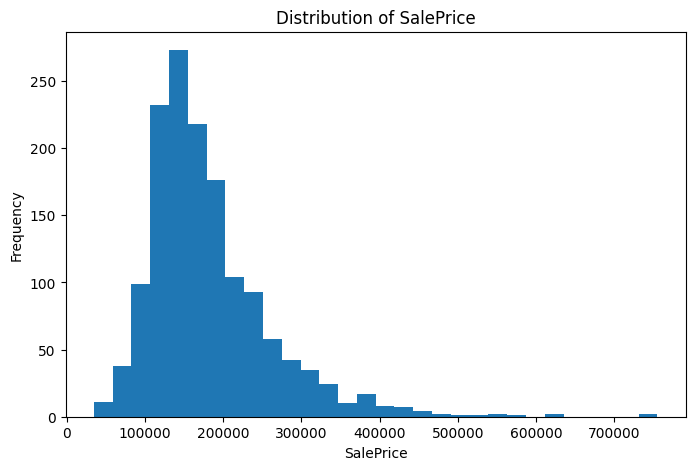

In [4]:
print(y.describe())

plt.figure(figsize=(8, 5))
plt.hist(y, bins=30)
plt.xlabel("SalePrice")
plt.ylabel("Frequency")
plt.title("Distribution of SalePrice")
plt.show()

count    1460.000000
mean       12.024051
std         0.399452
min        10.460242
25%        11.775097
50%        12.001505
75%        12.273731
max        13.534473
Name: SalePrice, dtype: float64


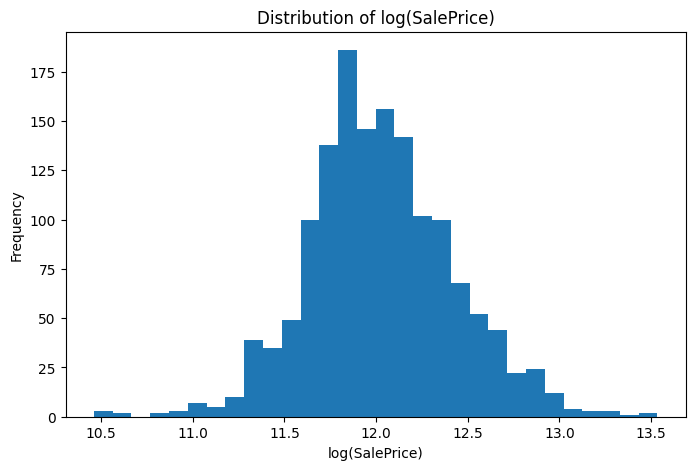

In [5]:
y_log = np.log(train_df["SalePrice"])

print(y_log.describe())

plt.figure(figsize=(8, 5))
plt.hist(y_log, bins=30)
plt.xlabel("log(SalePrice)")
plt.ylabel("Frequency")
plt.title("Distribution of log(SalePrice)")
plt.show()

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)

X_train shape: (1168, 80)
X_val shape: (292, 80)
y_train shape: (1168,)
y_val shape: (292,)


In [7]:
numeric_cols = X_train.select_dtypes(include=["number"]).columns
categorical_cols = X_train.select_dtypes(exclude=["number"]).columns

print("Number of numeric columns:", len(numeric_cols))
print("Number of categorical columns:", len(categorical_cols))
print()

print("Some numeric columns:")
print(list(numeric_cols[:10]))
print()

print("Some categorical columns:")
print(list(categorical_cols[:10]))
print()

print("Missing values in X_train:", X_train.isnull().sum().sum())
print("Missing values in X_val:", X_val.isnull().sum().sum())
print("Missing values in X_test:", X_test.isnull().sum().sum())

Number of numeric columns: 37
Number of categorical columns: 43

Some numeric columns:
['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1']

Some categorical columns:
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1']

Missing values in X_train: 6227
Missing values in X_val: 1602
Missing values in X_test: 7878


In [8]:
numeric_features = [col for col in numeric_cols if col != "Id"]

X_train_num = X_train[numeric_features].copy()
X_val_num = X_val[numeric_features].copy()
X_test_num = X_test[numeric_features].copy()

print("X_train_num shape:", X_train_num.shape)
print("X_val_num shape:", X_val_num.shape)
print("X_test_num shape:", X_test_num.shape)
print()

print("Missing values in X_train_num:", X_train_num.isnull().sum().sum())
print("Missing values in X_val_num:", X_val_num.isnull().sum().sum())
print("Missing values in X_test_num:", X_test_num.isnull().sum().sum())

X_train_num shape: (1168, 36)
X_val_num shape: (292, 36)
X_test_num shape: (1459, 36)

Missing values in X_train_num: 287
Missing values in X_val_num: 61
Missing values in X_test_num: 330


In [9]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_train_num_imputed = pd.DataFrame(
    imputer.fit_transform(X_train_num),
    columns=X_train_num.columns,
    index=X_train_num.index
)

X_val_num_imputed = pd.DataFrame(
    imputer.transform(X_val_num),
    columns=X_val_num.columns,
    index=X_val_num.index
)

X_test_num_imputed = pd.DataFrame(
    imputer.transform(X_test_num),
    columns=X_test_num.columns,
    index=X_test_num.index
)

print("Missing values in X_train_num_imputed:", X_train_num_imputed.isnull().sum().sum())
print("Missing values in X_val_num_imputed:", X_val_num_imputed.isnull().sum().sum())
print("Missing values in X_test_num_imputed:", X_test_num_imputed.isnull().sum().sum())

Missing values in X_train_num_imputed: 0
Missing values in X_val_num_imputed: 0
Missing values in X_test_num_imputed: 0


In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error

linear_model = LinearRegression()
linear_model.fit(X_train_num_imputed, y_train)

y_val_pred = linear_model.predict(X_val_num_imputed)

rmse_val = root_mean_squared_error(y_val, y_val_pred)

print("Validation RMSE on log(SalePrice):", rmse_val)

Validation RMSE on log(SalePrice): 0.15186289853955975


In [11]:
val_results = pd.DataFrame({
    "Actual_log_price": y_val,
    "Predicted_log_price": y_val_pred
})

val_results["Actual_price"] = np.exp(val_results["Actual_log_price"])
val_results["Predicted_price"] = np.exp(val_results["Predicted_log_price"])
val_results["Absolute_error"] = abs(val_results["Actual_price"] - val_results["Predicted_price"])
val_results["Percentage_error"] = (
    val_results["Absolute_error"] / val_results["Actual_price"] * 100
)

val_results[["Actual_price", "Predicted_price", "Absolute_error", "Percentage_error"]].head(10)

,Actual_price,Predicted_price,Absolute_error,Percentage_error
892,154500.0,154923.634657,423.634657,0.274197
1105,325000.0,305552.684798,19447.315202,5.983789
413,115000.0,116173.863590,1173.863590,1.020751
522,159000.0,173060.833928,14060.833928,8.843292
1036,315500.0,304160.054947,11339.945053,3.594277
614,75500.0,84525.932878,9025.932878,11.954878
218,311500.0,233222.351150,78277.648850,25.129261
1160,146000.0,150291.869888,4291.869888,2.939637
649,84500.0,84513.338901,13.338901,0.015786
887,135500.0,142680.863576,7180.863576,5.299530


In [12]:
val_results_sorted = val_results.sort_values("Percentage_error", ascending=False)

val_results_sorted[["Actual_price", "Predicted_price", "Absolute_error", "Percentage_error"]].head(10)

,Actual_price,Predicted_price,Absolute_error,Percentage_error
30,40000.0,87152.729114,47152.729114,117.881823
812,55993.0,108624.933985,52631.933985,93.997346
916,35311.0,67077.234829,31766.234829,89.961301
1432,64500.0,102326.352733,37826.352733,58.645508
874,66500.0,104899.801623,38399.801623,57.744063
772,107000.0,151631.224346,44631.224346,41.711425
588,143000.0,200961.696974,57961.696974,40.532655
628,135000.0,185626.205250,50626.205250,37.500893
898,611657.0,402799.789622,208857.210378,34.146133
1216,112000.0,149073.183789,37073.183789,33.101057


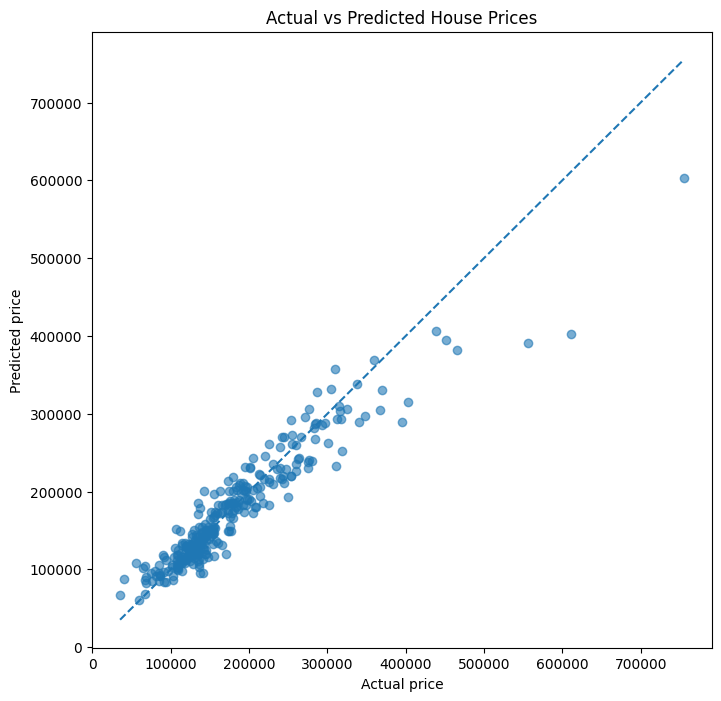

In [13]:
plt.figure(figsize=(8, 8))
plt.scatter(val_results["Actual_price"], val_results["Predicted_price"], alpha=0.6)

min_price = min(val_results["Actual_price"].min(), val_results["Predicted_price"].min())
max_price = max(val_results["Actual_price"].max(), val_results["Predicted_price"].max())

plt.plot([min_price, max_price], [min_price, max_price], linestyle="--")
plt.xlabel("Actual price")
plt.ylabel("Predicted price")
plt.title("Actual vs Predicted House Prices")
plt.show()

In [14]:
y_train_pred = linear_model.predict(X_train_num_imputed)

rmse_train = root_mean_squared_error(y_train, y_train_pred)

print("Training RMSE on log(SalePrice):", rmse_train)
print("Validation RMSE on log(SalePrice):", rmse_val)
print("Gap (val - train):", rmse_val - rmse_train)

Training RMSE on log(SalePrice): 0.14403817835750465
Validation RMSE on log(SalePrice): 0.15186289853955975
Gap (val - train): 0.0078247201820551


In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression

numeric_features = X_train.select_dtypes(include=["number"]).columns.drop("Id")
categorical_features = X_train.select_dtypes(exclude=["number"]).columns

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

full_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

full_model.fit(X_train, y_train)

y_val_pred_full = full_model.predict(X_val)
rmse_val_full = root_mean_squared_error(y_val, y_val_pred_full)

print("Validation RMSE with numeric + categorical features:", rmse_val_full)

Validation RMSE with numeric + categorical features: 0.14194773149902185


In [16]:
y_train_pred_full = full_model.predict(X_train)

rmse_train_full = root_mean_squared_error(y_train, y_train_pred_full)

print("Training RMSE with numeric + categorical features:", rmse_train_full)
print("Validation RMSE with numeric + categorical features:", rmse_val_full)
print("Gap (val - train):", rmse_val_full - rmse_train_full)

Training RMSE with numeric + categorical features: 0.11130072493447747
Validation RMSE with numeric + categorical features: 0.14194773149902185
Gap (val - train): 0.030647006564544374


In [17]:
from sklearn.linear_model import Ridge

ridge_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=10.0))
])

ridge_model.fit(X_train, y_train)

y_train_pred_ridge = ridge_model.predict(X_train)
y_val_pred_ridge = ridge_model.predict(X_val)

rmse_train_ridge = root_mean_squared_error(y_train, y_train_pred_ridge)
rmse_val_ridge = root_mean_squared_error(y_val, y_val_pred_ridge)

print("Ridge training RMSE:", rmse_train_ridge)
print("Ridge validation RMSE:", rmse_val_ridge)
print("Gap (val - train):", rmse_val_ridge - rmse_train_ridge)

Ridge training RMSE: 0.1433799494064619
Ridge validation RMSE: 0.14841207006663729
Gap (val - train): 0.005032120660175388


In [18]:
alphas = [0.01, 0.1, 1.0, 10.0, 100.0]

for alpha in alphas:
    ridge_model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", Ridge(alpha=alpha))
    ])

    ridge_model.fit(X_train, y_train)

    y_train_pred_ridge = ridge_model.predict(X_train)
    y_val_pred_ridge = ridge_model.predict(X_val)

    rmse_train_ridge = root_mean_squared_error(y_train, y_train_pred_ridge)
    rmse_val_ridge = root_mean_squared_error(y_val, y_val_pred_ridge)

    print(
        f"alpha={alpha:<6} | "
        f"train RMSE={rmse_train_ridge:.6f} | "
        f"val RMSE={rmse_val_ridge:.6f} | "
        f"gap={rmse_val_ridge - rmse_train_ridge:.6f}"
    )

alpha=0.01   | train RMSE=0.143380 | val RMSE=0.148438 | gap=0.005058
alpha=0.1    | train RMSE=0.143381 | val RMSE=0.148404 | gap=0.005023
alpha=1.0    | train RMSE=0.143381 | val RMSE=0.148428 | gap=0.005047
alpha=10.0   | train RMSE=0.143380 | val RMSE=0.148412 | gap=0.005032
alpha=100.0  | train RMSE=0.143652 | val RMSE=0.148830 | gap=0.005178


In [19]:
from sklearn.preprocessing import StandardScaler

numeric_features = X_train.select_dtypes(include=["number"]).columns.drop("Id")
categorical_features = X_train.select_dtypes(exclude=["number"]).columns

numeric_transformer_scaled = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_scaled = ColumnTransformer(transformers=[
    ("num", numeric_transformer_scaled, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

alphas = [0.01, 0.1, 1.0, 10.0, 100.0]

for alpha in alphas:
    ridge_model_scaled = Pipeline(steps=[
        ("preprocessor", preprocessor_scaled),
        ("model", Ridge(alpha=alpha))
    ])

    ridge_model_scaled.fit(X_train, y_train)

    y_train_pred = ridge_model_scaled.predict(X_train)
    y_val_pred = ridge_model_scaled.predict(X_val)

    rmse_train = root_mean_squared_error(y_train, y_train_pred)
    rmse_val = root_mean_squared_error(y_val, y_val_pred)

    print(
        f"alpha={alpha:<6} | "
        f"train RMSE={rmse_train:.6f} | "
        f"val RMSE={rmse_val:.6f} | "
        f"gap={rmse_val - rmse_train:.6f}"
    )

alpha=0.01   | train RMSE=0.092028 | val RMSE=0.127765 | gap=0.035737
alpha=0.1    | train RMSE=0.092746 | val RMSE=0.127753 | gap=0.035007
alpha=1.0    | train RMSE=0.098637 | val RMSE=0.131740 | gap=0.033103
alpha=10.0   | train RMSE=0.110440 | val RMSE=0.136104 | gap=0.025664
alpha=100.0  | train RMSE=0.124834 | val RMSE=0.140849 | gap=0.016015


In [20]:
alphas_fine = [0.03, 0.05, 0.1, 0.2, 0.3, 0.5]

for alpha in alphas_fine:
    ridge_model_scaled = Pipeline(steps=[
        ("preprocessor", preprocessor_scaled),
        ("model", Ridge(alpha=alpha))
    ])

    ridge_model_scaled.fit(X_train, y_train)

    y_train_pred = ridge_model_scaled.predict(X_train)
    y_val_pred = ridge_model_scaled.predict(X_val)

    rmse_train = root_mean_squared_error(y_train, y_train_pred)
    rmse_val = root_mean_squared_error(y_val, y_val_pred)

    print(
        f"alpha={alpha:<5} | "
        f"train RMSE={rmse_train:.6f} | "
        f"val RMSE={rmse_val:.6f} | "
        f"gap={rmse_val - rmse_train:.6f}"
    )

alpha=0.03  | train RMSE=0.092127 | val RMSE=0.127503 | gap=0.035376
alpha=0.05  | train RMSE=0.092276 | val RMSE=0.127401 | gap=0.035125
alpha=0.1   | train RMSE=0.092746 | val RMSE=0.127753 | gap=0.035007
alpha=0.2   | train RMSE=0.093719 | val RMSE=0.129043 | gap=0.035323
alpha=0.3   | train RMSE=0.094585 | val RMSE=0.129926 | gap=0.035341
alpha=0.5   | train RMSE=0.096032 | val RMSE=0.130812 | gap=0.034780
